# Phase 1.7 — Milk fermentation (yogurt) virtual lab

Unlike chromatography or UF/DF, a milk fermentation is a *messy*, *indirect* experiment: the
only thing measured online is a **pH time series**, which rolls up biomass growth, lactose
consumption, lactic-acid production and flavour development into one curve. The classic
screening readout is simply the **time to reach a target pH**, and it shifts with the
strain(s) used.

`models/fermentation` is a **stochastic, mechanism-flavoured generator** for exactly this:

- multi-strain **Baranyi–Roberts** growth with a **Rosso** cardinal-temperature law,
- *S. thermophilus* ↔ *L. bulgaricus* **proto-cooperation**,
- **Luedeking–Piret** acid production → milk **buffering** titration curve → pH,
- three explicit randomness layers — batch **variability**, an optional process-noise **SDE**,
  and pH-probe measurement **uncertainty**,
- a product **fingerprint** + distance for the **strain-replacement** problem.

This notebook walks through: a single batch, strain personalities & cooperation, uncertainty
vs variability, a temperature×inoculum DoE, and matching a reference product fingerprint.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

from downstream_doe.config import make_rng
from downstream_doe.models import fermentation as ferm

T_GRID = np.linspace(0, 12, 481)        # 12 h, fine grid (hours)
rng = make_rng(2026)

## 1 — A single yogurt batch: one pH curve, many latent states

The pH is all the lab sees, but underneath it the model tracks biomass per strain, lactose,
lactic acid and aroma. Note the milestones: **gelation** (pH 5.2) and the **set point**
(pH 4.6).

gelation (pH 5.2) at 4.06 h | set point (pH 4.6) at 6.95 h
final pH 4.32 | post-acidification 0.28 pH


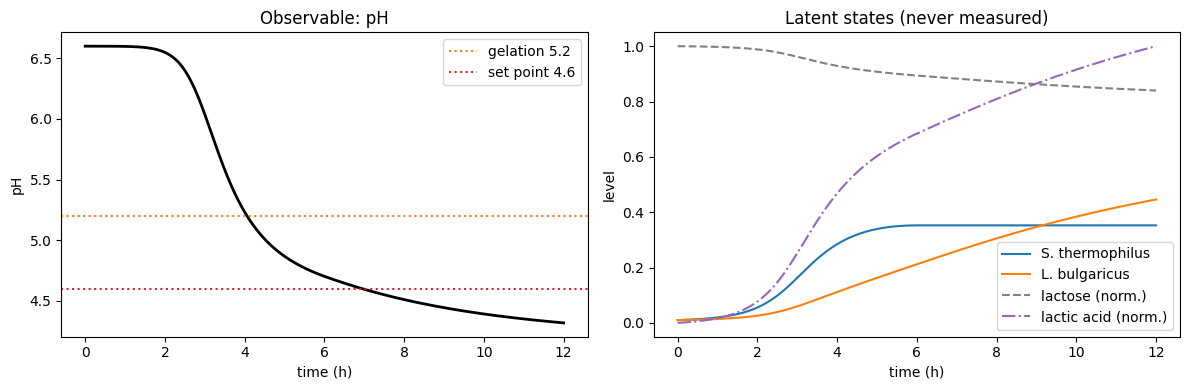

In [2]:
setup = ferm.FermentationSetup(consortium=ferm.yogurt_blend(fraction_st=0.5, fraction_lb=0.5),
                               temperature=43.0)
r = ferm.run_fermentation(setup, T_GRID)
fp = ferm.fingerprint(r)
print(f"gelation (pH 5.2) at {fp['t_gel']:.2f} h | set point (pH 4.6) at {fp['t_set']:.2f} h")
print(f"final pH {fp['final_ph']:.2f} | post-acidification {fp['post_acidification']:.2f} pH")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(r.t, r.ph, 'k', lw=2)
ax1.axhline(ferm.PH_GEL, ls=':', c='tab:orange', label='gelation 5.2')
ax1.axhline(ferm.PH_SET, ls=':', c='tab:red', label='set point 4.6')
ax1.set(xlabel='time (h)', ylabel='pH', title='Observable: pH'); ax1.legend()

for name, x in zip(r.strain_names, r.biomass):
    ax2.plot(r.t, x, label=name)
ax2.plot(r.t, r.substrate / r.substrate[0], '--', c='gray', label='lactose (norm.)')
ax2.plot(r.t, r.lactic_acid / r.lactic_acid.max(), '-.', c='tab:purple', label='lactic acid (norm.)')
ax2.set(xlabel='time (h)', ylabel='level', title='Latent states (never measured)'); ax2.legend()
plt.tight_layout()

## 2 — Strain personalities and proto-cooperation

*S. thermophilus* (ST) is the fast early acidifier but is acid-sensitive, so **alone it
stalls** above the set point. *L. bulgaricus* (LB) is slower but acid-tolerant and finishes
the job. Together they **cooperate**: turning cooperation off, the same mix barely sets —
this is the textbook yogurt symbiosis.

culture          t_gel   t_set  final_pH
ST only           4.55     nan      4.72
LB only           5.59    7.92      4.32
ST+LB (coop)      3.91    6.51      4.29
ST+LB (indep)     4.86   10.23      4.52


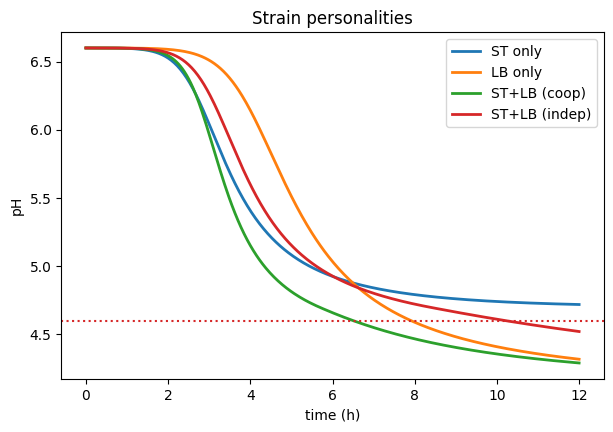

In [3]:
cases = {
    'ST only':     ferm.single_strain(ferm.streptococcus_thermophilus()),
    'LB only':     ferm.single_strain(ferm.lactobacillus_bulgaricus()),
    'ST+LB (coop)':ferm.yogurt_blend(0.5, 0.5, cooperation=1.5),
    'ST+LB (indep)':ferm.yogurt_blend(0.5, 0.5, cooperation=0.0),
}
fig, ax = plt.subplots(figsize=(7, 4.5))
rows = []
for label, cons in cases.items():
    rr = ferm.run_fermentation(ferm.FermentationSetup(consortium=cons, temperature=43.0), T_GRID)
    ax.plot(rr.t, rr.ph, lw=2, label=label)
    f = ferm.fingerprint(rr)
    rows.append((label, f['t_gel'], f['t_set'], f['final_ph']))
ax.axhline(ferm.PH_SET, ls=':', c='tab:red'); ax.set(xlabel='time (h)', ylabel='pH'); ax.legend()
ax.set_title('Strain personalities')

print(f"{'culture':14s}{'t_gel':>8s}{'t_set':>8s}{'final_pH':>10s}")
for label, tg, ts, fpH in rows:
    print(f"{label:14s}{tg:8.2f}{ts:8.2f}{fpH:10.2f}")

## 3 — Uncertainty vs variability

Three independent sources of randomness, deliberately kept separate:

1. **measurement uncertainty** — the pH probe noise on *one* batch (epistemic),
2. **batch variability** — biological lot-to-lot spread of *whole batches* (aleatoric),
3. **process noise** — an SDE making a single batch's trajectory wobble.

The batch-variability band is what you must beat (or characterise) to compare strains
reliably.

set-time across batches: mean 7.26 h, sd 0.88 h


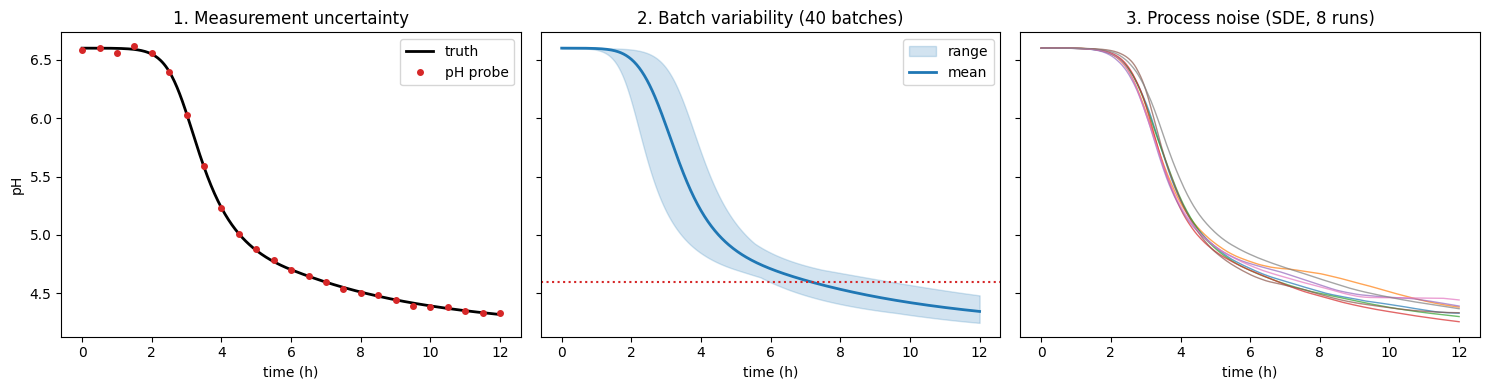

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# (1) measurement uncertainty on one clean batch
sample_t = np.linspace(0, 12, 25)
obs = ferm.observe_ph(r, sample_t, rng=rng)
axes[0].plot(r.t, r.ph, 'k', lw=2, label='truth')
axes[0].plot(obs['t'], obs['ph'], 'o', ms=4, c='tab:red', label='pH probe')
axes[0].set(title='1. Measurement uncertainty', xlabel='time (h)', ylabel='pH'); axes[0].legend()

# (2) batch-to-batch variability
batches = ferm.run_batches(setup, ferm.BatchVariability(), 40, T_GRID, rng)
B = np.array([b.ph for b in batches])
axes[1].fill_between(T_GRID, B.min(0), B.max(0), alpha=0.2, color='tab:blue', label='range')
axes[1].plot(T_GRID, B.mean(0), c='tab:blue', lw=2, label='mean')
axes[1].axhline(ferm.PH_SET, ls=':', c='tab:red')
axes[1].set(title='2. Batch variability (40 batches)', xlabel='time (h)'); axes[1].legend()

# (3) within-batch process noise (SDE)
sde = ferm.FermentationSetup(consortium=ferm.yogurt_blend(), temperature=43.0, process_noise_sd=0.2)
for _ in range(8):
    rs = ferm.run_fermentation(sde, T_GRID, rng=rng)
    axes[2].plot(rs.t, rs.ph, lw=1, alpha=0.7)
axes[2].set(title='3. Process noise (SDE, 8 runs)', xlabel='time (h)')
plt.tight_layout()

t_sets = np.array([ferm.time_to_ph(b.t, b.ph, 4.6) for b in batches])
print(f"set-time across batches: mean {np.nanmean(t_sets):.2f} h, sd {np.nanstd(t_sets):.2f} h")

## 4 — A temperature × inoculum design

`time_to_ph(4.6)` is the screening response. Sweeping the two main process factors on a grid
(a full-factorial / response-surface design — `doe/factorial` and `doe/lhs` plug straight in)
shows the optimum temperature ridge near the ST/LB cardinal optima and the speed-up from a
heavier pitch.

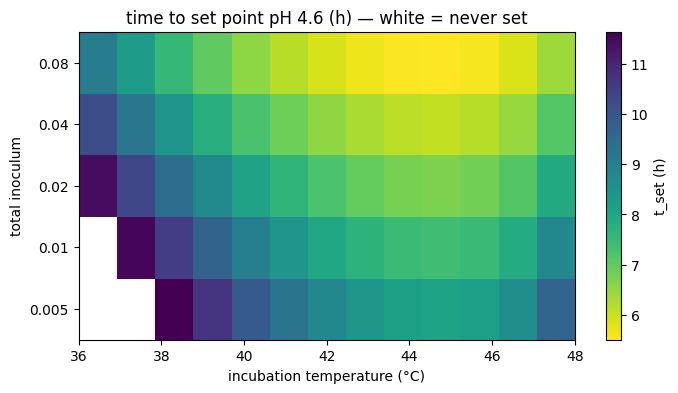

In [5]:
temps = np.linspace(36, 48, 13)
inocs = np.array([0.005, 0.01, 0.02, 0.04, 0.08])
Z = np.full((len(inocs), len(temps)), np.nan)
for i, x0 in enumerate(inocs):
    for j, T in enumerate(temps):
        s = ferm.FermentationSetup(consortium=ferm.yogurt_blend(), temperature=T, total_inoculum=x0)
        rr = ferm.run_fermentation(s, T_GRID)
        Z[i, j] = ferm.time_to_ph(rr.t, rr.ph, 4.6)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis_r',
               extent=[temps[0], temps[-1], 0, len(inocs)])
ax.set_yticks(np.arange(len(inocs)) + 0.5); ax.set_yticklabels(inocs)
ax.set(xlabel='incubation temperature (°C)', ylabel='total inoculum',
       title='time to set point pH 4.6 (h) — white = never set')
fig.colorbar(im, ax=ax, label='t_set (h)')

## 5 — Strain replacement: match a reference product

The realistic goal is usually *replace an incumbent culture with a new blend that makes the
same product*. We take a reference fingerprint (the incumbent), then search blend ratio ×
temperature to **minimise the fingerprint distance** to it — the objective that drops straight
into `optimization/bayesopt`.

closest match: ST fraction 0.60, temperature 44.0 °C  (distance 0.079)


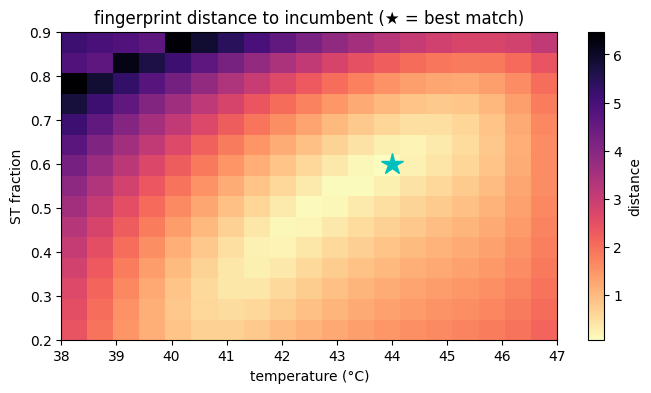

In [6]:
# Incumbent ("legacy") culture we must reproduce after it is discontinued.
incumbent = ferm.FermentationSetup(consortium=ferm.yogurt_blend(0.65, 0.35, cooperation=1.3),
                                   temperature=44.0)
ref_fp = ferm.fingerprint(ferm.run_fermentation(incumbent, T_GRID))

# Search the available recipe space (ST fraction × temperature) for the closest match.
fracs = np.linspace(0.2, 0.9, 15)
temps = np.linspace(38, 47, 19)
best = None
D = np.full((len(fracs), len(temps)), np.nan)
for i, fst in enumerate(fracs):
    for j, T in enumerate(temps):
        cand = ferm.FermentationSetup(consortium=ferm.yogurt_blend(fst, 1 - fst), temperature=T)
        fp_c = ferm.fingerprint(ferm.run_fermentation(cand, T_GRID))
        d = ferm.fingerprint_distance(fp_c, ref_fp)
        D[i, j] = d
        if best is None or d < best[0]:
            best = (d, fst, T)

print(f"closest match: ST fraction {best[1]:.2f}, temperature {best[2]:.1f} °C  (distance {best[0]:.3f})")
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(D, origin='lower', aspect='auto', cmap='magma_r',
               extent=[temps[0], temps[-1], fracs[0], fracs[-1]])
ax.plot(best[2], best[1], 'c*', ms=16)
ax.set(xlabel='temperature (°C)', ylabel='ST fraction',
       title='fingerprint distance to incumbent (★ = best match)')
fig.colorbar(im, ax=ax, label='distance')